In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent

RESULTS_DIR = PROJECT_ROOT / "results"
IMAGES_DIR = PROJECT_ROOT / "images"

RESULTS_DIR.mkdir(exist_ok=True)
IMAGES_DIR.mkdir(exist_ok=True)

print("Final figure generation started.")

Final figure generation started.


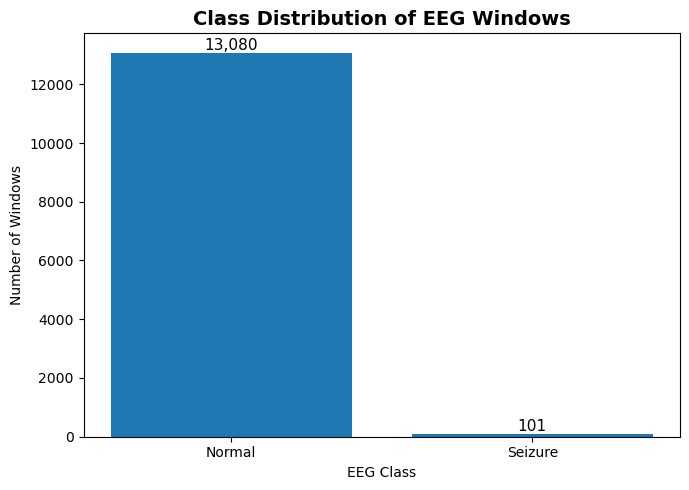

In [2]:
normal_windows = 13080
seizure_windows = 101

labels = ["Normal", "Seizure"]
counts = [normal_windows, seizure_windows]

plt.figure(figsize=(7, 5))

bars = plt.bar(labels, counts)

plt.title(
    "Class Distribution of EEG Windows",
    fontsize=14,
    fontweight="bold"
)

plt.ylabel("Number of Windows")
plt.xlabel("EEG Class")

for bar, count in zip(bars, counts):
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height(),
        f"{count:,}",
        ha="center",
        va="bottom",
        fontsize=11
    )

plt.tight_layout()

plt.savefig(
    IMAGES_DIR / "figure_2_dataset_class_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

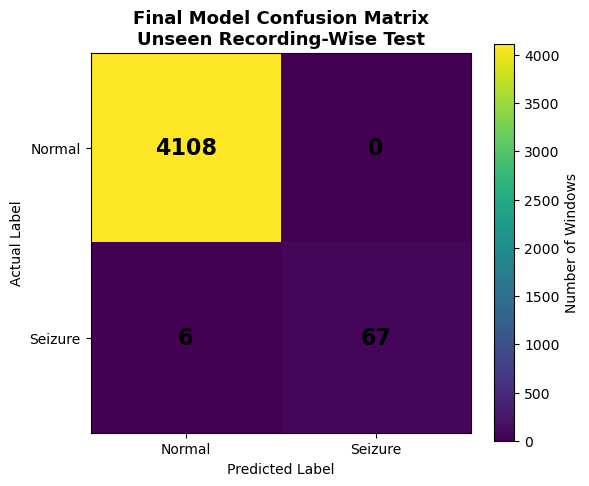

In [3]:
cm = np.array([
    [4108, 0],
    [6, 67]
])

plt.figure(figsize=(6, 5))

plt.imshow(cm)

plt.title(
    "Final Model Confusion Matrix\nUnseen Recording-Wise Test",
    fontsize=13,
    fontweight="bold"
)

plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")

plt.xticks(
    [0, 1],
    ["Normal", "Seizure"]
)

plt.yticks(
    [0, 1],
    ["Normal", "Seizure"]
)

for i in range(2):
    for j in range(2):
        plt.text(
            j,
            i,
            str(cm[i, j]),
            ha="center",
            va="center",
            fontsize=16,
            fontweight="bold"
        )

plt.colorbar(label="Number of Windows")

plt.tight_layout()

plt.savefig(
    IMAGES_DIR / "figure_3_final_confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

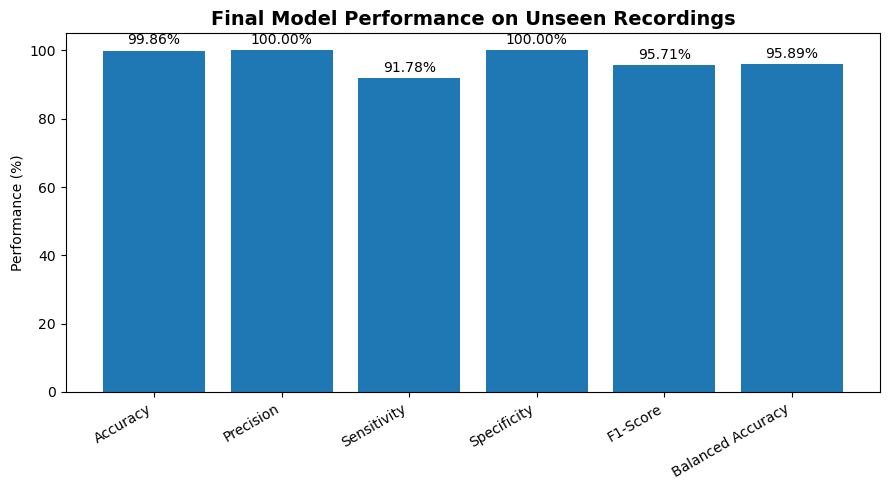

In [4]:
metrics = [
    "Accuracy",
    "Precision",
    "Sensitivity",
    "Specificity",
    "F1-Score",
    "Balanced Accuracy"
]

values = [
    99.86,
    100.00,
    91.78,
    100.00,
    95.71,
    95.89
]

plt.figure(figsize=(9, 5))

bars = plt.bar(metrics, values)

plt.title(
    "Final Model Performance on Unseen Recordings",
    fontsize=14,
    fontweight="bold"
)

plt.ylabel("Performance (%)")
plt.ylim(0, 105)

plt.xticks(rotation=30, ha="right")

for bar, value in zip(bars, values):
    plt.text(
        bar.get_x() + bar.get_width()/2,
        value + 1,
        f"{value:.2f}%",
        ha="center",
        va="bottom",
        fontsize=10
    )

plt.tight_layout()

plt.savefig(
    IMAGES_DIR / "figure_4_final_model_performance.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

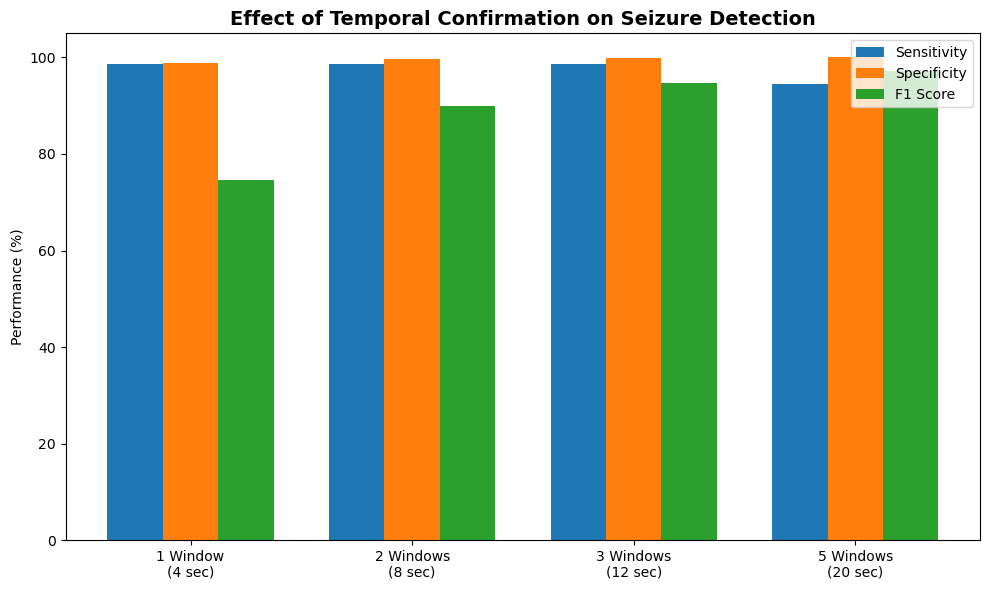

In [5]:
temporal_df = pd.DataFrame({
    "Confirmation": [
        "1 Window\n(4 sec)",
        "2 Windows\n(8 sec)",
        "3 Windows\n(12 sec)",
        "5 Windows\n(20 sec)"
    ],
    "Sensitivity": [
        98.6301,
        98.6301,
        98.6301,
        94.5205
    ],
    "Specificity": [
        98.8315,
        99.6349,
        99.8296,
        100.0000
    ],
    "F1 Score": [
        74.6114,
        90.0000,
        94.7368,
        97.1831
    ]
})

x = np.arange(len(temporal_df))

width = 0.25

plt.figure(figsize=(10, 6))

plt.bar(
    x - width,
    temporal_df["Sensitivity"],
    width,
    label="Sensitivity"
)

plt.bar(
    x,
    temporal_df["Specificity"],
    width,
    label="Specificity"
)

plt.bar(
    x + width,
    temporal_df["F1 Score"],
    width,
    label="F1 Score"
)

plt.xticks(
    x,
    temporal_df["Confirmation"]
)

plt.ylabel("Performance (%)")

plt.title(
    "Effect of Temporal Confirmation on Seizure Detection",
    fontsize=14,
    fontweight="bold"
)

plt.ylim(0, 105)

plt.legend()

plt.tight_layout()

plt.savefig(
    IMAGES_DIR / "figure_5_temporal_confirmation_analysis.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

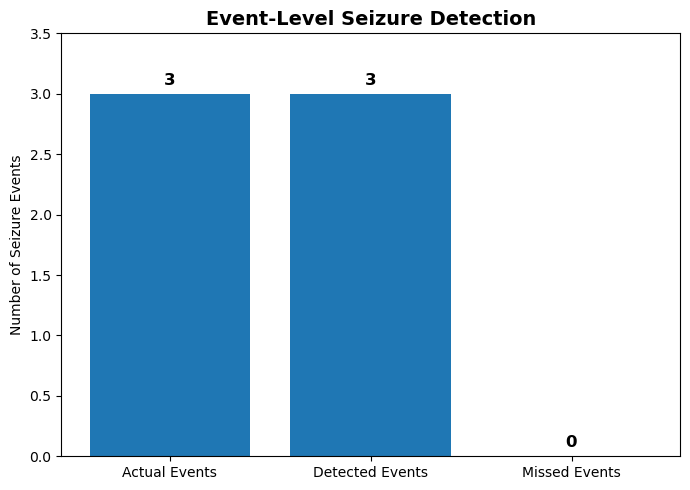

In [6]:
event_labels = [
    "Actual Events",
    "Detected Events",
    "Missed Events"
]

event_counts = [
    3,
    3,
    0
]

plt.figure(figsize=(7, 5))

bars = plt.bar(
    event_labels,
    event_counts
)

plt.title(
    "Event-Level Seizure Detection",
    fontsize=14,
    fontweight="bold"
)

plt.ylabel("Number of Seizure Events")

plt.ylim(0, 3.5)

for bar, count in zip(bars, event_counts):
    plt.text(
        bar.get_x() + bar.get_width()/2,
        count + 0.05,
        str(count),
        ha="center",
        va="bottom",
        fontsize=12,
        fontweight="bold"
    )

plt.tight_layout()

plt.savefig(
    IMAGES_DIR / "figure_6_event_level_detection.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()